# ERA5 Atmospheric Profiles

Integration of ERA5 reanalysis data for realistic atmospheric profile input to radiative transfer simulations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import gcsfs
import os

# we use the GCSFileSystem to access the ERA5 data stored in Google Cloud Storage
gcs = gcsfs.GCSFileSystem(token='anon')
path = 'gs://gcp-public-data-arco-era5/ar/1959-2022-6h-128x64_equiangular_with_poles_conservative.zarr/'
full_era5 = xr.open_zarr(gcs.get_mapper(path), chunks='auto')
#full_era5.to_netcdf('../data/era5_6h_128x64.nc', engine='h5netcdf')

/projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
module 'numpy' has no attribute 'cumproduct'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [2]:
full_era5

<xarray.Dataset> Size: 326GB
Dimensions:                                           (time: 92040,
                                                       longitude: 128,
                                                       latitude: 64, level: 13)
Coordinates:
  * latitude                                          (latitude) float64 512B ...
  * level                                             (level) int64 104B 50 ....
  * longitude                                         (longitude) float64 1kB ...
  * time                                              (time) datetime64[ns] 736kB ...
Data variables: (12/38)
    10m_u_component_of_wind                           (time, longitude, latitude) float32 3GB dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    10m_v_component_of_wind                           (time, longitude, latitude) float32 3GB dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    10m_wind_speed                                    (time, longitude, latitude) float32 3GB dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    2m_temperature                                    (time, longitude, latitude) float32 3GB dask.array<chunksize=(40, 128, 64), meta=np.ndarray>
    angle_of_sub_gridscale_orography                  (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    anisotropy_of_sub_gridscale_orography             (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    ...                                                ...
    type_of_high_vegetation                           (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    type_of_low_vegetation                            (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    u_component_of_wind                               (time, level, longitude, latitude) float32 39GB dask.array<chunksize=(40, 13, 128, 64), meta=np.ndarray>
    v_component_of_wind                               (time, level, longitude, latitude) float32 39GB dask.array<chunksize=(40, 13, 128, 64), meta=np.ndarray>
    vertical_velocity                                 (time, level, longitude, latitude) float32 39GB dask.array<chunksize=(40, 13, 128, 64), meta=np.ndarray>
    wind_speed                                        (time, level, longitude, latitude) float32 39GB dask.array<chunksize=(40, 13, 128, 64), meta=np.ndarray>

In [3]:
era5_to_sim = full_era5.rename({
    'sea_surface_temperature': 'surface_temperature',
    'temperature': 't',
    'specific_humidity': 'q',
    'geopotential': 'z',
    'level': 'pressure_level',
    'time' : 'valid_time',
})



### manually add ozone profile if not present
if 'o3' not in era5_to_sim.data_vars:
    # Use a constant profile for ozone, e.g., 300 DU
    # Convert DU to number density (1 DU = 2.687e19 molecules/m^2)
    # Assume a standard atmosphere for conversion
    altitude_km = era5_to_sim['z'] / 1000.0  # Convert geopotential height to km
    o3_profile = xr.DataArray(
        data=300e-6 * 2.687e19 * np.exp(-altitude_km / 8.5),  # Example exponential decay
        dims=era5_to_sim['z'].dims,
        coords=era5_to_sim['z'].coords,
        name='o3'
    )
    era5_to_sim = era5_to_sim.assign(o3=o3_profile)


In [4]:
# Import PyRadtran components using NEW IO system
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/thermal_config.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

N_timesteps = 2

# stationary simulation at constant altitude, latitude, and longitude but with varying time
# be aware that the max altitude needs to be lower than the max altitude in the ERA5 data

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2020-04-04T08:00:00', periods=N_timesteps, freq='h'),
        'latitude' : ('time', [61.5] * N_timesteps),
        'longitude' : ('time', [22.0] * N_timesteps),
        'altitude' : ('altitude', np.arange(0, 11, 1)),
    }
)



# load the ERA5 data for the specified space and time // this didn't make it faster...
ds_era5_local = era5_to_sim.sel(
    latitude=ds['latitude'],
    longitude=ds['longitude'],
    valid_time=ds['time'],
    method='nearest'
).load()

In [5]:
ds_sim = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=False,
    era5_atmosphere=era5_to_sim,
)

## Distance between Requested Point and Nearest ERA5 Point

Compare the distance between the requested point and the nearest ERA5 point with the `haversine` function.

In [6]:

def haversine(lon1, lat1, lon2, lat2):
    # convert decimal degrees to radians
    lon1 = np.deg2rad(lon1)
    lon2 = np.deg2rad(lon2)
    lat1 = np.deg2rad(lat1)
    lat2 = np.deg2rad(lat2)

    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371
    return c * r

In [7]:
distances = haversine(
    ds['longitude'].values,
    ds['latitude'].values,
    ds_era5_local['longitude'].values,
    ds_era5_local['latitude'].values
)

print(f"Distances to nearest ERA5 point: {distances} km")

Distances to nearest ERA5 point: [27.72135351 27.72135351] km


## Investigating the simulation results

As the simulation results are stored in an xarray dataset, you can use the xarray plotting capabilities to visualize the results.

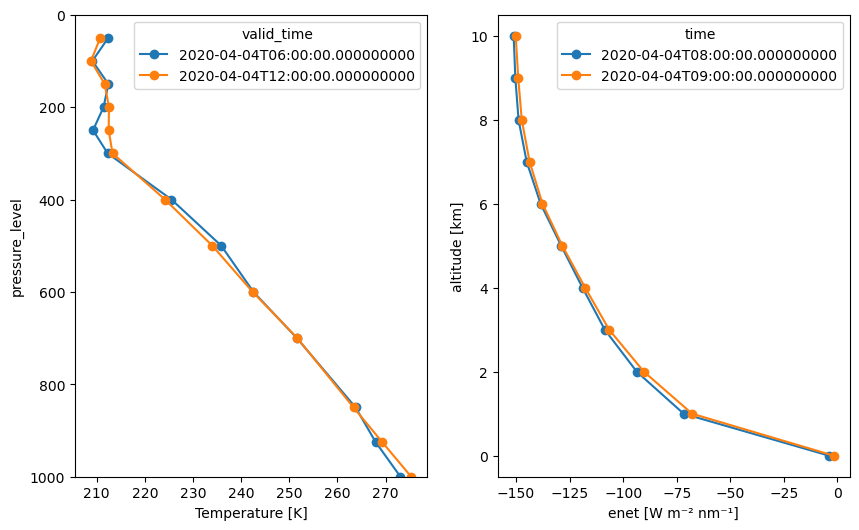

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ds_sim.enet.plot(
    hue='time',
    y='altitude',
    marker='o',
    ax=ax[1],
)

ds_era5_local.t.plot(
    hue='valid_time',
    y='pressure_level',
    marker='o',
    ax=ax[0],
    ylim=(1000, 0),  # Pressure levels are inverted#
)